## 1. Overview & Data Cleaning
In this section, I loaded the Titanic dataset and performed the following cleaning steps:
* **Missing Values:** Imputed the median for `Age` and dropped the `Cabin` column due to excessive missing data.
* **Feature Engineering:** Created a `FamilySize` feature to track total relatives on board and an `AgeGroup` feature to categorize passengers into life stages (Child, Teen, Adult, etc.).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset from your uploaded file
# If your file is inside a folder, use 'folder_name/titanic.csv'
df = pd.read_csv('Titanic-Dataset.csv')

# 2. Handle missing values (as per task requirements)
# Fill Age with the median to handle missing entries without being affected by outliers
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop the 'Cabin' column because it has too many missing values
df.drop(columns=['Cabin'], inplace=True)

# Drop the few rows where 'Embarked' is missing
df.dropna(subset=['Embarked'], inplace=True)

# 3. Feature Engineering
# Feature 1: FamilySize (Siblings + Parents + the passenger themselves)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Feature 2: AgeGroup (Categorizing ages into life stages)
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Display completion message and data preview
print("Step 1: Data Preparation Complete!")
print(f"Dataset shape: {df.shape}")
df.head()

Step 1: Data Preparation Complete!
Dataset shape: (889, 13)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Young Adult


In [8]:
%pip install seaborn

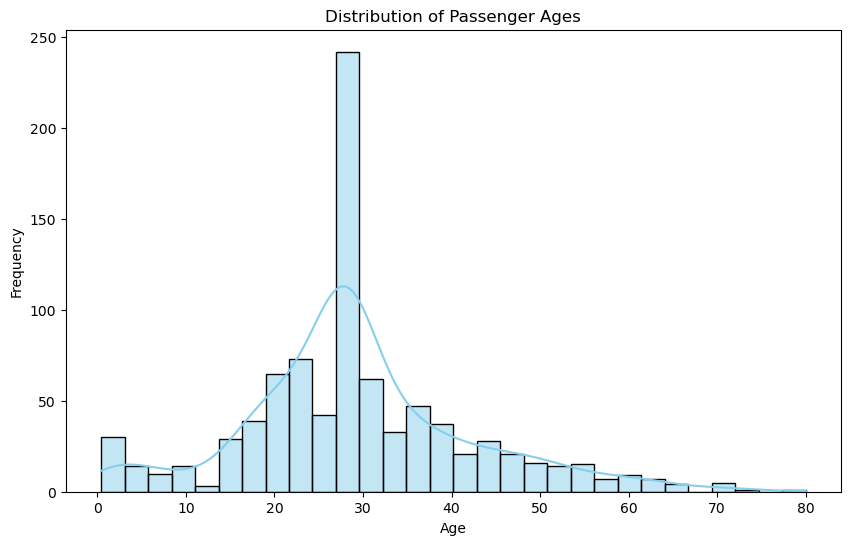

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The majority of passengers were young adults between the ages of 20 and 35. The distribution is slightly right-skewed, with a significant number of children present on board.

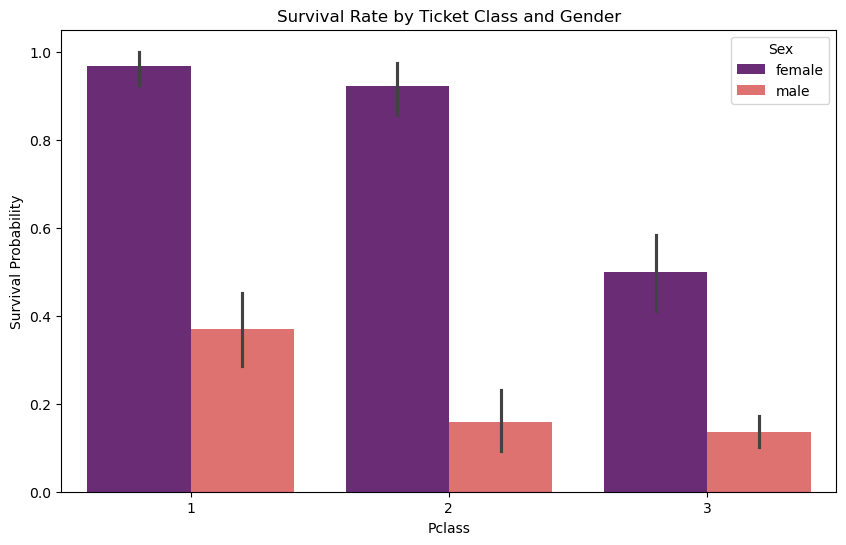

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='magma')
plt.title('Survival Rate by Ticket Class and Gender')
plt.ylabel('Survival Probability')
plt.show()

Females in 1st and 2nd class had the highest survival rates (near 90-100%), while males in 2nd and 3rd class had the lowest, highlighting the strong correlation between gender, social status, and survival.

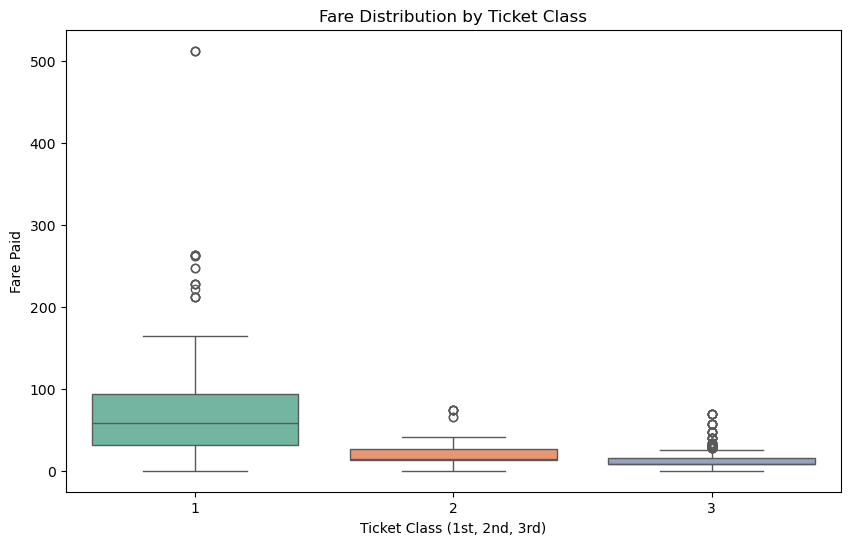

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Pclass', y='Fare', data=df, hue='Pclass', palette='Set2', legend=False)

plt.title('Fare Distribution by Ticket Class')
plt.xlabel('Ticket Class (1st, 2nd, 3rd)')
plt.ylabel('Fare Paid')
plt.show()

The boxplot clearly shows that 1st class passengers paid significantly higher fares, with several extreme outliers reaching over £500. In contrast, 2nd and 3rd class fares are much lower and show very little variation compared to the luxury tier.

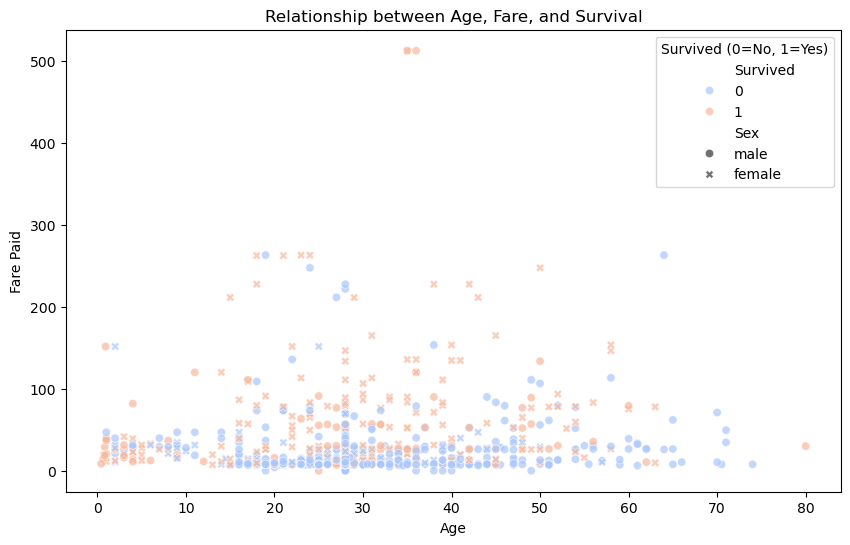

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Sex', data=df, alpha=0.7, palette='coolwarm')
plt.title('Relationship between Age, Fare, and Survival')
plt.xlabel('Age')
plt.ylabel('Fare Paid')
plt.legend(title='Survived (0=No, 1=Yes)', loc='upper right')
plt.show()

There is a noticeable cluster of survivors (blue points) among the passengers who paid higher fares, regardless of their age. Most of the casualties (red points) are concentrated in the lower fare range, illustrating that wealth played a significant role in survival chances.

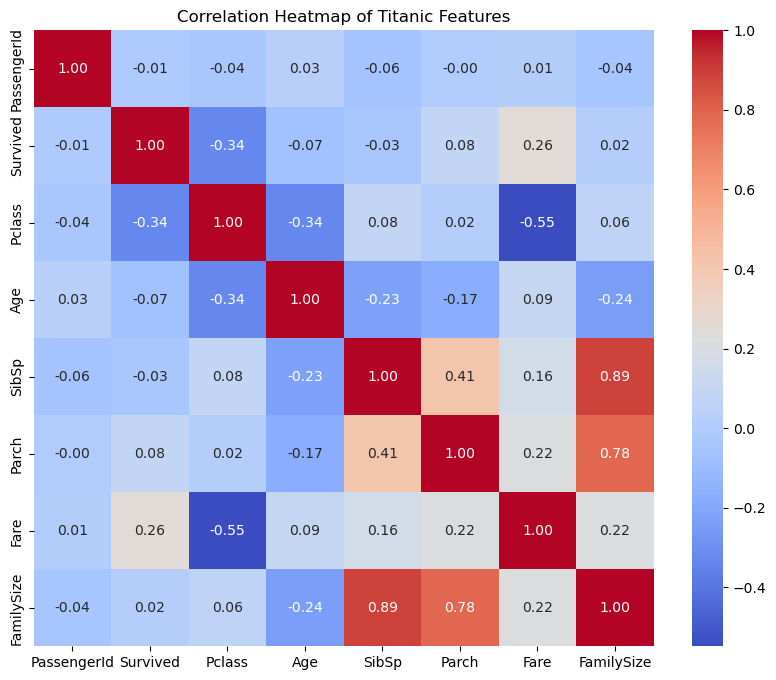

In [17]:
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Titanic Features')
plt.show()

There is a notable negative correlation between Pclass and Fare, confirming that 1st class tickets were significantly more expensive. FamilySize also shows a positive correlation with SibSp and Parch, as expected from feature engineering.